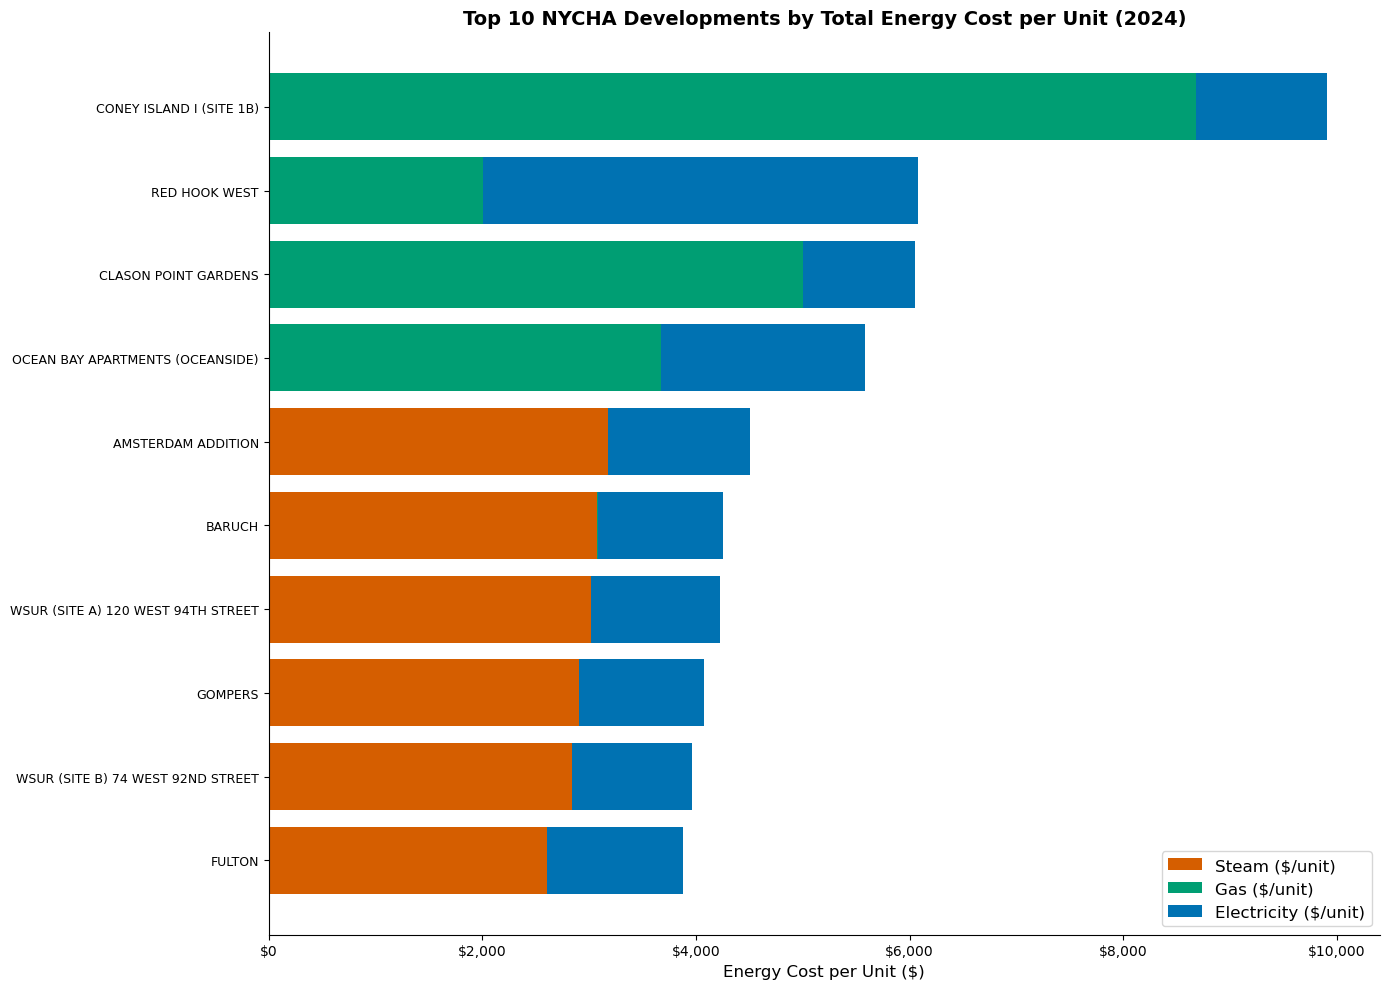

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

base = Path().resolve()
while not (base / "readme.md").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data/processed/combined_utilities_2024.csv")

# Load authoritative apartment counts from NYCHA Development Data Book
ddb = pd.read_csv(base / "data/raw/NYCHA_Development_Data_Book_20260314.csv")
ddb_apts = ddb[['TDS#', 'CONSOLIDATED TDS#', 'TOTAL NUMBER OF APARTMENTS']].copy()

# Clean TDS#: take first number from comma-separated values, strip asterisks, fall back to CONSOLIDATED TDS#
ddb_apts['tds_#'] = (
    ddb_apts['TDS#']
    .str.replace(r'\*', '', regex=True)          # strip asterisks (e.g. "079*")
    .str.split(',').str[0]                        # take first of comma-separated (e.g. "082, 582" → "082")
    .fillna(ddb_apts['CONSOLIDATED TDS#'])        # fall back to consolidated TDS#
    .str.strip()
)
ddb_apts['tds_#'] = pd.to_numeric(ddb_apts['tds_#'], errors='coerce')
ddb_apts = ddb_apts.dropna(subset=['tds_#'])
ddb_apts['tds_#'] = ddb_apts['tds_#'].astype(int)
ddb_apts = ddb_apts.rename(columns={'TOTAL NUMBER OF APARTMENTS': 'ddb_apartments'})
ddb_apts['ddb_apartments'] = pd.to_numeric(ddb_apts['ddb_apartments'].str.replace(',', ''), errors='coerce')
ddb_apts = ddb_apts[['tds_#', 'ddb_apartments']]

# Merge Data Book apartment counts into utilities data
df = df.merge(ddb_apts, on='tds_#', how='left')

# Group by TDS — charges are TDS-level totals repeated on every BBL row,
# so take the first value rather than summing (which would overcount)
tds = df.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'total_units': g['ddb_apartments'].iloc[0],  # authoritative count from Data Book
        'total_steam_charges': g['steam_current_charges'].iloc[0],
        'total_gas_charges': g['gas_current_charges'].iloc[0],
        'total_elec_charges': g['electricity_current_charges'].iloc[0],
    }),
    include_groups=False,
).reset_index(drop=True)

# Recalculate per-unit costs at the TDS level using Data Book apartment counts
tds['steam_cost_per_unit'] = tds['total_steam_charges'] / tds['total_units']
tds['gas_cost_per_unit'] = tds['total_gas_charges'] / tds['total_units']
tds['elec_cost_per_unit'] = tds['total_elec_charges'] / tds['total_units']
tds['total_cost_per_unit'] = (
    tds['steam_cost_per_unit'].fillna(0) + tds['gas_cost_per_unit'].fillna(0) + tds['elec_cost_per_unit'].fillna(0)
)

# Top 10 TDSs by total cost per unit
top10 = tds.nlargest(10, 'total_cost_per_unit').sort_values('total_cost_per_unit', ascending=True)

steam_vals = top10['steam_cost_per_unit'].fillna(0).values
gas_vals = top10['gas_cost_per_unit'].fillna(0).values
elec_vals = top10['elec_cost_per_unit'].fillna(0).values
labels = top10['development'].values

# Horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(14, 10))
y = np.arange(len(labels))

ax.barh(y, steam_vals, label='Steam ($/unit)', color='#D55E00')
ax.barh(y, gas_vals, left=steam_vals, label='Gas ($/unit)', color='#009E73')
ax.barh(y, elec_vals, left=steam_vals + gas_vals, label='Electricity ($/unit)', color='#0072B2')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Energy Cost per Unit ($)', fontsize=12)
ax.set_title('Top 10 NYCHA Developments by Total Energy Cost per Unit (2024)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()